<a href="https://colab.research.google.com/github/Lorenasaquicoray/Applied-Machine-Learning/blob/main/Computer_Vision_Filters_and_Perceptrons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Computer Vision Filters and Perceptrons

Each of the items below will require you to perform a task and you will need to research how to accomplish those tasks. Just like ‘real world’ job tasks there is no textbook to guide you through all of the steps. There are however several resources you can use to help steer you through the lab, such as programming library documentation, Google, ChatGPT, etc.

You may complete the exercises as given below, or you may combine them all in a single code block. Please make it clear which exercise each portion of the code and each output correspond to.

## Part One: Perceptron

1. Create a perceptron with the following:

    a. 2 weighted inputs

    b. 1 bias

    c. A step activation function

    d. 1 output

2. Create some sample input and print the resulting output.

3. Modify the weights and repeat step 2.

In [ ]:
import numpy as np

#math
class Perceptron:
  def __init__(self, input_size, bias =-2):
    self.weights = np.random.randn(input_size) #random weights inside the class
    self.bias = bias


  #step activation
  def activation(self, x):
    return 1 if x >= 0 else 0

  def predict(self, inputs):
    #math = (input1*weight1)+(input2*weight2)+bias
    summation = np.dot(inputs, self.weights) + self.bias
    return self.activation(summation)


#Creating perceptron
#assigned 2 inputs
neuron = Perceptron(input_size=2)
neuron.weights= np.array([3, 4])
sample_input = np.array([1, 1])

result1 = neuron.predict(sample_input)
print(result1)


#modifying weights
neuron.weights = [1, 1]
input2 = np.array([-7, 12])
result2 = neuron.predict(input2)
print(result2)


1
1


## Part Two: Perceptron Learning

1. Copy the code you used to solve part one. Modify the code to randomly initialize the weight values.

2. Create a ‘learning loop’ that will update the weights using the perceptron learning algorithm (see the lecture slides for the algorithm).

3. Output the total number of iterations and the final value of the weights. (Repeat this experiment if you ‘got lucky’ and it worked with the first random weights.)

4. Show that the perceptron learns the AND gate and then the OR gate.

In [ ]:
import numpy as np

#math
class Perceptron:
  def __init__(self, input_size, bias=-2):
    self.weights = np.random.randn(input_size) #random weights inside the class
    self.bias = bias

  #step activation
  def activation(self, x):
    return 1 if x >= 0 else 0

  def predict(self, inputs):
    summation = np.dot(inputs, self.weights) + self.bias
    return self.activation(summation)

  # Learning loop for AND gate
  def training(self, inputs, targets, learning_rate=0.1, epochs=100):
    iterations = 0
    for epoch in range(epochs):
      iterations += 1
      #we are assuming that the result is perfect until prove wrong
      converged = True

      #go through every row and column comparing with expected and result
      for x,d in zip(inputs, targets):
        y = self.predict(x) #letting the machine guess first
        if y != d:
          converged = False
          self.weights += learning_rate * (d - y) * x
          self.bias += learning_rate * (d - y)
      if converged:
        break
    print(f"Iterations: {iterations}") # Modified to print iterations with a label
    print(f"Final weights: {self.weights}") # Modified to print final weights with a label
    #return iterations


#Creating perceptron
neuron = Perceptron(input_size=2)
print(f"Initial random weights: {neuron.weights}")
print(f"Initial bias: {neuron.bias}")

# Define AND gate inputs and outputs
and_inputs = np.array([[0, 0],
                       [0, 1],
                       [1, 0],
                       [1, 1]])
and_outputs = np.array([0, 0, 0, 1])

print("\nTraining for AND gate ")
# Train the perceptron for AND gate
neuron.training(and_inputs, and_outputs)

# Define OR gate inputs and outputs
or_inputs = np.array([[0, 0],
                      [0, 1],
                      [1, 0],
                      [1, 1]])
or_outputs = np.array([0, 1, 1, 1])

print("\nTraining for OR gate")
# Create a new perceptron for OR gate or reinitialize weights if reusing the same one
# Creating a new neuron to make sure it does not interfere with the other one
or_neuron = Perceptron(input_size=2)
print(f"Initial random weights for OR gate: {or_neuron.weights}")
print(f"Initial bias for OR gate: {or_neuron.bias}")

# Train the perceptron for OR gate
or_neuron.training(or_inputs, or_outputs)

Initial random weights: [-0.16001722 -0.30372832]
Initial bias: -2

Training for AND gate 
Iterations: 10
Final weights: [0.73998278 0.59627168]

Training for OR gate
Initial random weights for OR gate: [1.08353125 1.07617149]
Initial bias for OR gate: -2
Iterations: 5
Final weights: [1.38353125 1.47617149]


## Part Three: Filters

1. Load in a grayscale image (or convert a color image to grayscale) and display it to the screen.

2. Create a custom 3x3 smoothing filter and apply it to the image (with zero padding for borders). Output the resulting image and the original image in the same window. (Note: by custom I mean define what the 3x3 matrix is).

3. Repeat the above step for a 9x9 and 15x15 filter.

4. Now repeat steps 2 and 3, but instead of zero padding, pad the image by mirroring it over the border.

5. Apply a step function intensity threshold to your image: that is, for some threshold $\theta$, all pixels whose intensities are greater than or equal to $\theta$ should be set to full intensity (255), and all pixels whose intensities are less than $\theta$ should be set to zero. You may choose whichever threshold you like.

6. Apply an edge detection filter to your image (e.g., the Canny edge detector). Display both the original image and its filtered output in the same set of axes.

Image loaded and converted to grayscale.


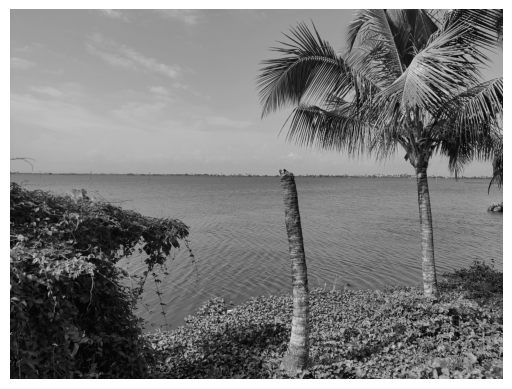

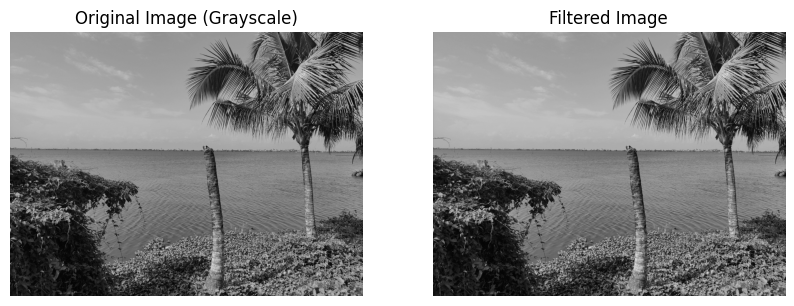

In [ ]:
from matplotlib import image
import cv2
import numpy as np
import matplotlib.pyplot as plt

#loading grayscale image
image1 = cv2.imread("lab3.jpg") # Loads the image as color (BGR)

# Check if the image was loaded successfully
grayscale_image = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY) # Convert to grayscale
print("Image loaded and converted to grayscale.")
plt.axis('off')
plt.imshow(grayscale_image, cmap='gray') # Display the grayscale image
plt.show()

#3x3 filter
kernel = np.array([
    [3,3,5],
    [6,6,1],
    [0,7,1]
                  ])
#normalizing kernel
kernel = kernel / np.sum(kernel)

#padding with 0
# Make sure grayscale_image is defined before padding
padding_image= np.pad(grayscale_image,1, mode='constant', constant_values=0) # Apply padding to grayscale_image

#applying filter -> convolution
filtered_image = np.zeros_like(grayscale_image,dtype=np.float32) # Initialize filtered_image for grayscale

for i in range(grayscale_image.shape[0]):
  for j in range(grayscale_image.shape[1]):
    region= padding_image[i:i+kernel.shape[0], j:j+kernel.shape[1]]
    filtered_image[i,j] = np.sum(region*kernel)

filtered_image = np.clip(filtered_image,0,255).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Original Image (Grayscale)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(filtered_image, cmap='gray')
plt.title('Filtered Image')
plt.axis('off')

plt.show()


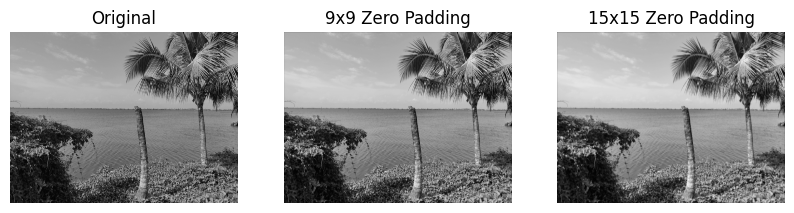

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Creating a helper function to make the code more brief and no repetitive
def apply_filter(image, kernel, padding_mode):
  pad_size = kernel.shape[0] // 2
  padded= np.pad(image, pad_size, mode=padding_mode)

  output = np.zeros_like(image, dtype=np.float32)

  #looping through every pixel
  for i in range(image.shape[0]):
    for j in range(image.shape[1]):
      region = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
      output[i,j] = np.sum(region * kernel)

  return np.clip(output, 0, 255).astype(np.uint8)

#9x9 kernel -> 0 padding

kernel_9 = np.ones((9,9), dtype=np.float32) / (9*9) # Corrected normalization
filtered_9 = apply_filter(grayscale_image, kernel_9, 'constant')


#15x15 kernel -> 0 padding

kernel_15 = np.ones((15,15), dtype=np.float32) / (15*15) # Corrected normalization
filtered_15 = apply_filter(grayscale_image, kernel_15, 'constant')


#displaying results

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(filtered_9, cmap='gray')
plt.title('9x9 Zero Padding')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(filtered_15,cmap='gray')
plt.title('15x15 Zero Padding')
plt.axis('off')

plt.show()

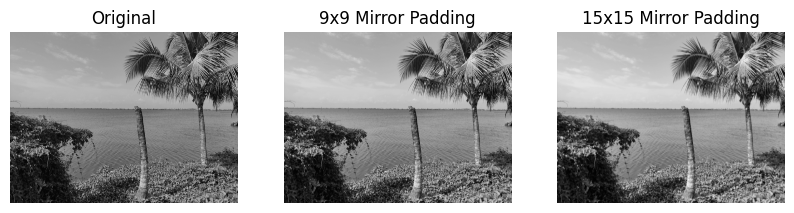

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


filtered_9_mirror = apply_filter(grayscale_image, kernel_9, 'reflect')
filtered_15_mirror = apply_filter(grayscale_image, kernel_15, 'reflect')

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(grayscale_image,cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(filtered_9_mirror, cmap='gray')
plt.title('9x9 Mirror Padding')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(filtered_15_mirror, cmap='gray')
plt.title('15x15 Mirror Padding')
plt.axis('off')

plt.show()

5. Apply a step function intensity threshold to your image: that is, for some threshold $\theta$, all pixels whose intensities are greater than or equal to $\theta$ should be set to full intensity (255), and all pixels whose intensities are less than $\theta$ should be set to zero. You may choose whichever threshold you like.


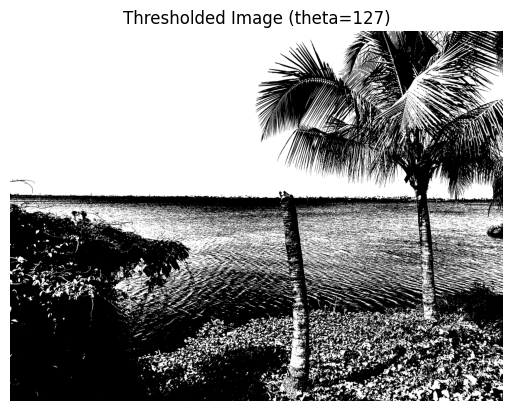

In [ ]:
theta = 127
_, thresholded_image = cv2.threshold(grayscale_image, theta, 255, cv2.THRESH_BINARY)

plt.imshow(thresholded_image, cmap='gray')
plt.title(f"Thresholded Image (theta={theta})")
plt.axis('off')
plt.show()


6. Apply an edge detection filter to your image (e.g., the Canny edge detector). Display both the original image and its filtered output in the same set of axes.

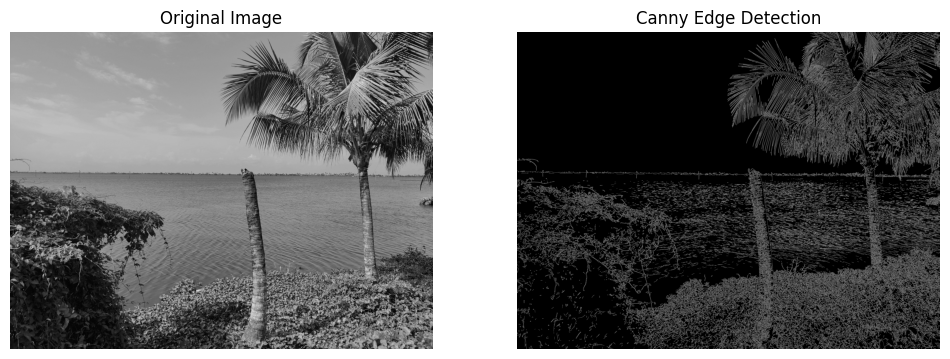

In [ ]:
# Apply Canny Edge Detection
edges = cv2.Canny(grayscale_image, 100, 200)

# Display original and edges in the same set of axes
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original Image subplot
ax[0].imshow(grayscale_image, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')  # Turn off axis for the first plot

# Canny Edge subplot
ax[1].imshow(edges, cmap='gray')
ax[1].set_title("Canny Edge Detection")
ax[1].axis('off')  # Turn off axis for the second plot

plt.show()